In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torchvision import datasets, transforms

In [2]:
# Load MNIST dataset using torchvision
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

# Extract data and labels
X_train = train_dataset.data.numpy()
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.41MB/s]


In [3]:
len(X_train)

60000

In [4]:
len(X_test)

10000

In [5]:
X_train[0].shape

(28, 28)

In [6]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

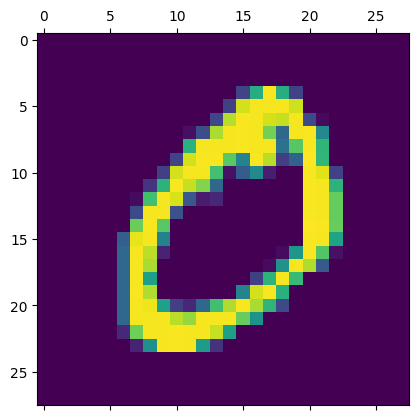

In [29]:
plt.matshow(X_train[1])

In [8]:
y_train[0]

np.int64(5)

In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [11]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

# Convert to PyTorch tensors
X_train_flattened = torch.FloatTensor(X_train_flattened)
y_train_tensor = torch.LongTensor(y_train)
X_test_flattened = torch.FloatTensor(X_test_flattened)
y_test_tensor = torch.LongTensor(y_test)

In [12]:
X_train_flattened.shape

torch.Size([60000, 784])

In [13]:
X_train_flattened[0]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [34]:
# Define the model
model = nn.Sequential(
    nn.Linear(784, 10),
    nn.Sigmoid()
)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Create DataLoader
train_dataset = TensorDataset(X_train_flattened, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        total_loss += loss.item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

Epoch [1/10], Loss: 1.6753, Accuracy: 86.08%
Epoch [2/10], Loss: 1.5895, Accuracy: 89.60%
Epoch [3/10], Loss: 1.5745, Accuracy: 90.30%
Epoch [4/10], Loss: 1.5668, Accuracy: 90.61%
Epoch [5/10], Loss: 1.5619, Accuracy: 90.86%
Epoch [6/10], Loss: 1.5585, Accuracy: 91.06%
Epoch [7/10], Loss: 1.5558, Accuracy: 91.27%
Epoch [8/10], Loss: 1.5537, Accuracy: 91.32%
Epoch [9/10], Loss: 1.5520, Accuracy: 91.44%
Epoch [10/10], Loss: 1.5505, Accuracy: 91.55%


In [35]:
# Evaluate the model
model.eval()

Sequential(
  (0): Linear(in_features=784, out_features=10, bias=True)
  (1): Sigmoid()
)

In [36]:
with torch.no_grad():
    outputs = model(X_test_flattened)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == y_test_tensor).sum().item()
    accuracy = 100 * correct / len(y_test_tensor)
    loss = criterion(outputs, y_test_tensor).item()
    print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.2f}%')

Test Loss: 1.5491, Test Accuracy: 91.48%


In [37]:
with torch.no_grad():
    y_predicted = model(X_test_flattened)
    y_predicted = torch.softmax(y_predicted, dim=1)
y_predicted[0]

tensor([0.0853, 0.0853, 0.0853, 0.0857, 0.0853, 0.0853, 0.0853, 0.2319, 0.0853,
        0.0853])

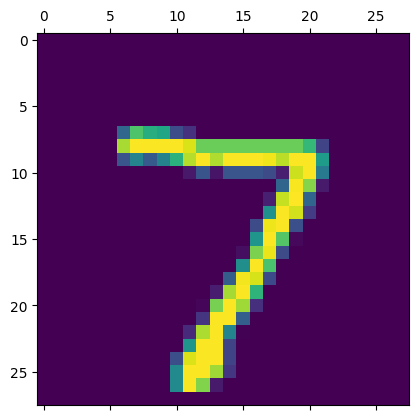

In [17]:
plt.matshow(X_test[0])

In [18]:
torch.argmax(y_predicted[0]).item()

7

In [19]:
y_predicted_labels = torch.argmax(y_predicted, dim=1).numpy()

In [20]:
y_predicted_labels[:5]

array([7, 2, 1, 0, 4])

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted_labels)
cm

array([[ 959,    0,    0,    1,    0,    3,    9,    1,    6,    1],
       [   0, 1104,    3,    2,    0,    2,    4,    2,   17,    1],
       [   6,    4,  900,   18,   15,    6,   10,   13,   56,    4],
       [   3,    1,   22,  914,    2,   20,    2,   13,   27,    6],
       [   1,    1,    5,    0,  891,    0,    6,    1,   12,   65],
       [  10,    3,    0,   32,   14,  766,   21,    4,   28,   14],
       [  11,    3,    6,    1,   10,   19,  901,    0,    7,    0],
       [   2,    7,   24,    2,   11,    1,    0,  945,    5,   31],
       [   8,    8,    7,   13,   10,   24,   10,   12,  879,    3],
       [   9,    6,    2,   13,   26,    9,    0,   25,    8,  911]])

Text(95.72222222222221, 0.5, 'Truth')

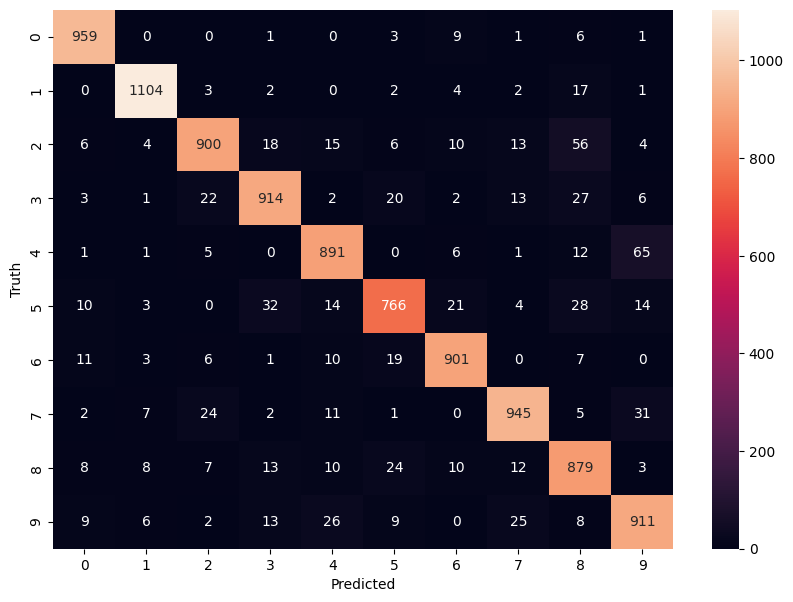

In [22]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [23]:
# Define the model with hidden layer
model = nn.Sequential(
    nn.Linear(784, 100),
    nn.ReLU(),

    nn.Linear(100, 10),
    nn.Sigmoid()
)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Create DataLoader
train_dataset = TensorDataset(X_train_flattened, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        total_loss += loss.item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

Epoch [1/5], Loss: 1.5871, Accuracy: 89.64%
Epoch [2/5], Loss: 1.5175, Accuracy: 94.32%
Epoch [3/5], Loss: 1.5035, Accuracy: 95.63%
Epoch [4/5], Loss: 1.4956, Accuracy: 96.47%
Epoch [5/5], Loss: 1.4904, Accuracy: 97.00%


In [24]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_flattened)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == y_test_tensor).sum().item()
    accuracy = 100 * correct / len(y_test_tensor)
    loss = criterion(outputs, y_test_tensor).item()
    print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.2f}%')

Test Loss: 1.4918, Test Accuracy: 96.90%


Text(95.72222222222221, 0.5, 'Truth')

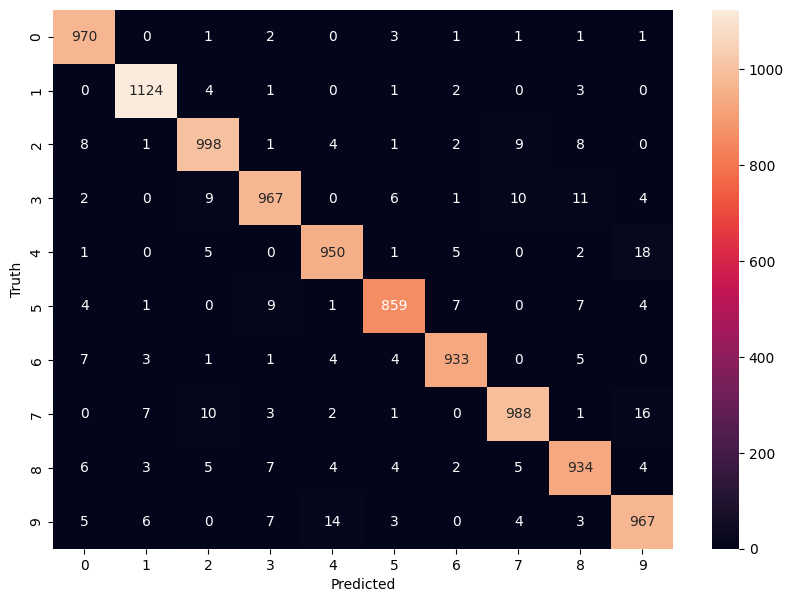

In [25]:
model.eval()
with torch.no_grad():
    y_predicted = model(X_test_flattened)
    y_predicted = torch.softmax(y_predicted, dim=1)
    y_predicted_labels = torch.argmax(y_predicted, dim=1).numpy()

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted_labels)

import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [26]:
# Define the model with Flatten layer
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 100),
    nn.ReLU(),
    nn.Linear(100, 10),
    nn.Sigmoid()
)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Convert original (non-flattened) data to tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        total_loss += loss.item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

Epoch [1/10], Loss: 1.5865, Accuracy: 89.73%
Epoch [2/10], Loss: 1.5186, Accuracy: 94.17%
Epoch [3/10], Loss: 1.5044, Accuracy: 95.55%
Epoch [4/10], Loss: 1.4960, Accuracy: 96.35%
Epoch [5/10], Loss: 1.4908, Accuracy: 96.94%
Epoch [6/10], Loss: 1.4869, Accuracy: 97.34%
Epoch [7/10], Loss: 1.4839, Accuracy: 97.58%
Epoch [8/10], Loss: 1.4813, Accuracy: 97.90%
Epoch [9/10], Loss: 1.4798, Accuracy: 98.00%
Epoch [10/10], Loss: 1.4780, Accuracy: 98.16%


In [27]:
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == y_test_tensor).sum().item()
    accuracy = 100 * correct / len(y_test_tensor)
    loss = criterion(outputs, y_test_tensor).item()
    print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.2f}%')

Test Loss: 1.4886, Test Accuracy: 97.20%
